In [9]:
from math import lgamma

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# How Safe Are Bitcoin Confirmations?
## A Probabilistic Analysis of Double-Spend Risk in Bitcoin Proof of Work

### Abstract
Bitcoin does not offer *absolute* transaction finality. Instead, the security of a confirmed transaction is probabilistic: an attacker who controls a fraction $q$ of the total hash power may still try to reverse a payment by secretly mining a competing chain. The central question of this project is therefore:

> **How quickly does double-spend risk decrease as the number of confirmations grows?**

### Central thesis
**Bitcoin confirmation security is probabilistic rather than absolute, and the practical safety of waiting for $z$ confirmations depends strongly on both the attacker's hash-power share $q$ and the mathematical method used to estimate the attacker's hidden progress.**


## 1. Introduction

Bitcoin uses **Proof of Work (PoW)** to decide which chain of blocks becomes the accepted history of transactions. Miners repeatedly compute hashes until one of them finds a valid block. Each accepted block extends the blockchain, and each additional block on top of a transaction is called a **confirmation**.

The folk intuition is that "more confirmations means more safety." That intuition is correct, but it is incomplete. The missing detail is that the protection is **probabilistic**, not deterministic. If an attacker pays a merchant and simultaneously begins mining a secret competing chain, then even after the merchant sees $z$ honest confirmations, the attacker may still succeed later by catching up and overtaking the honest chain.


### 1.1 Why this problem matters

The phrase "wait for six confirmations" is common in discussions of Bitcoin transaction security. However, such a rule only makes sense after answering at least three deeper questions:

1. **What stochastic process describes block discovery?**
2. **How should we model the attacker's hidden chain during the waiting period?**
3. **How fast does attack success probability actually decay as confirmations accumulate?**

A good mathematical model should not merely repeat folklore. It should explain *why* the rule works when it works, *when* it becomes weak, and *how* the result changes when the attacker controls more computational power.



### 1.2 Research questions and thesis

This project answers the following research questions.

1. **How can block discovery be modeled mathematically?**
2. **If the attacker is currently $d$ blocks behind, what is the probability of eventually catching up?**
3. **While the merchant waits for $z$ honest confirmations, how many secret blocks is the attacker likely to mine?**
4. **What is the exact double-spend success probability once we combine those two pieces?**
5. **How accurate is Nakamoto's Poisson approximation relative to the exact negative-binomial model?**
6. **How many confirmations are required to push risk below practical thresholds such as $10^{-2}$, $10^{-3}$, or $10^{-6}$?**

The thesis stated at the start of the notebook will be evaluated against the numerical results at the end.



## 2. Mathematical Background

To model Bitcoin confirmations rigorously, we first need a probabilistic description of mining itself. The important idea is that mining is not a deterministic race with a fixed finish time. It is a **random process** driven by a very large number of repeated hash attempts.


Throughout this section, the goal is not to use the most advanced theory possible. The goal is to start from simple probability models and build upward one step at a time.


### 2.1 Hashing as a Bernoulli process

Suppose that a single hash attempt succeeds with probability $s$, where success means "the hash is below the current target." Then each attempt is a **Bernoulli trial**:

$$
\Pr(\text{success}) = s, \qquad \Pr(\text{failure}) = 1-s.
$$

If $N$ is the number of independent attempts until the first success, then $N$ follows a **geometric distribution**:

$$
\Pr(N=n) = (1-s)^{n-1}s, \qquad n=1,2,3,\dots
$$

The geometric distribution is the right discrete model because:

- the trials are repeated independently,
- each trial has the same success probability $s$,
- and the process stops at the first success.

Two basic facts are immediately useful:

$$
\mathbb{E}[N] = \frac{1}{s}, \qquad
\mathrm{Var}(N) = \frac{1-s}{s^2}.
$$

These formulas say that when $s$ is extremely small, the expected number of trials before success is enormous. That is exactly the PoW setting: a block is *rare* relative to the number of attempted hashes.



### 2.2 From geometric waiting times to exponential block times

Mining hardware does not perform one hash every few minutes; it performs an enormous number of hashes per second. If a miner produces $r$ independent attempts per unit time, then after a short interval $\Delta t$ the success probability is approximately

$$
\Pr(\text{success in } \Delta t) \approx r s \, \Delta t.
$$

In the limit of many tiny time slices, the waiting time $T$ to the next block is modeled by an **exponential distribution** with rate $\lambda = rs$:

$$
f_T(t) = \lambda e^{-\lambda t}, \qquad t \ge 0,
$$

$$
\Pr(T > t) = e^{-\lambda t},
\qquad
\mathbb{E}[T] = \frac{1}{\lambda},
\qquad
\mathrm{Var}(T) = \frac{1}{\lambda^2}.
$$

This transition from a geometric count of trials to an exponential waiting time is not a change in underlying logic. It is the continuous-time limit of the same Bernoulli mechanism.

For Bitcoin, the protocol adjusts difficulty so that the *network-wide* expected inter-block time is close to 10 minutes. In our notation, that means

$$
\lambda_{\text{network}} \approx \frac{1}{10} \text{ blocks per minute}.
$$

An important conceptual consequence of the exponential model is the **memoryless property**: a long time without a block does not make a block "overdue." The probability law of the *remaining* waiting time is the same as it was at the beginning.



### 2.3 Simulating network block times

Before building the security model, it is useful to validate the exponential waiting-time intuition numerically. The code below draws many synthetic block intervals from an exponential distribution with mean 10 minutes and overlays the theoretical density

$$
f_T(t) = \lambda e^{-\lambda t}, \qquad \lambda = \frac{1}{10}.
$$

The purpose of this plot is not to "discover" the formula experimentally; the formula comes first. The simulation is a sanity check that helps connect the mathematics to an observable distribution.


In [10]:
# Plot settings
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

# Pandas display format
pd.options.display.float_format = "{:,.6f}".format

# Reproducibility
SEED = 42

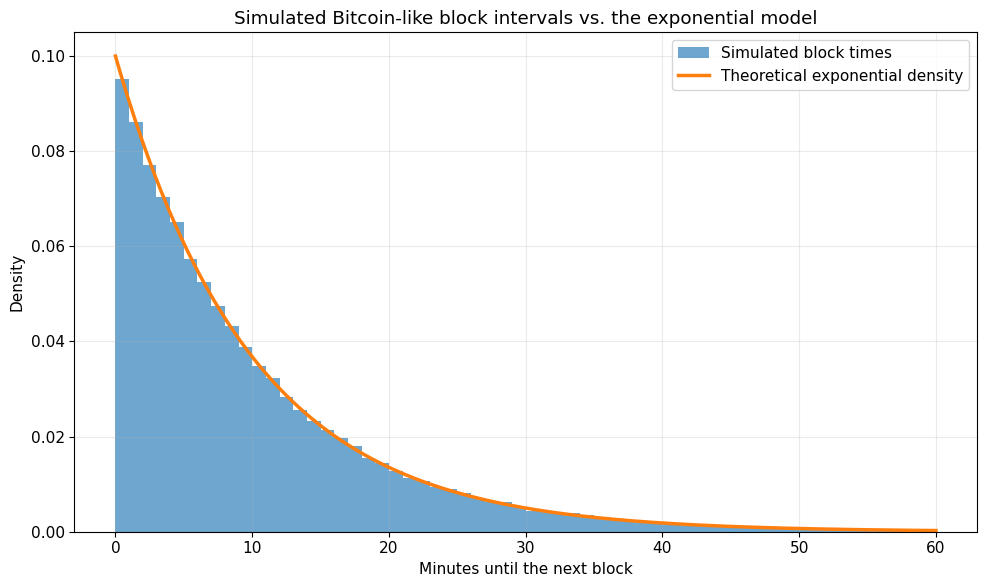

,Statistic,Value
0,Sample mean,10.034967
1,Theoretical mean,10.000000
2,Sample variance,101.061594
3,Theoretical variance,100.000000


In [5]:
def simulate_block_times(n_blocks, mean_minutes=10.0, seed=7):
    rng = np.random.default_rng(seed)
    return rng.exponential(scale=mean_minutes, size=n_blocks)


block_times = simulate_block_times(n_blocks=100_000, mean_minutes=10.0, seed=SEED)
rate = 1 / 10.0

x = np.linspace(0, 60, 500)
pdf = rate * np.exp(-rate * x)

fig, ax = plt.subplots()
ax.hist(block_times, bins=60, density=True, alpha=0.65, range=(0, 60), label="Simulated block times")
ax.plot(x, pdf, linewidth=2.5, label="Theoretical exponential density")
ax.set_title("Simulated Bitcoin-like block intervals vs. the exponential model")
ax.set_xlabel("Minutes until the next block")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
plt.show()

summary_block_times = pd.DataFrame(
    {
        "Statistic": ["Sample mean", "Theoretical mean", "Sample variance", "Theoretical variance"],
        "Value": [
            block_times.mean(),
            10.0,
            block_times.var(ddof=1),
            100.0,
        ],
    }
)
summary_block_times



The histogram follows the theoretical exponential shape quite closely. The main lesson is conceptual:

- **short waiting times are common,**
- **very long waiting times are possible but rare,**
- and **there is no deterministic schedule for the next block.**

That randomness is exactly what makes confirmation security a probabilistic question instead of a simple counting rule.



### 2.4 Competing Poisson processes

Now split the network into two groups:

- honest miners with hash-power share $p$,
- an attacker with hash-power share $q$,

with

$$
p+q=1, \qquad 0 < q < 1.
$$

If the whole network has block-arrival rate $\lambda$, then the two sides can be modeled as independent Poisson processes with rates

$$
\lambda_h = p\lambda, \qquad \lambda_a = q\lambda.
$$

Let $T_h \sim \mathrm{Exp}(\lambda_h)$ be the waiting time to the next honest block and $T_a \sim \mathrm{Exp}(\lambda_a)$ the waiting time to the next attacker block. Then the probability that the *next* block belongs to the attacker is

$$
\Pr(T_a < T_h)
= \frac{\lambda_a}{\lambda_a + \lambda_h}
= \frac{q\lambda}{q\lambda + p\lambda}
= q.
$$

Likewise,

$$
\Pr(T_h < T_a) = p.
$$

This result is crucial. It shows that once we focus on the **sequence of block discoveries**, the continuous-time race reduces to a simple discrete random walk in which each new block is honest with probability $p$ and attacker-generated with probability $q$.



## 3. Building the Double-Spend Model

We now turn the stochastic intuition into a security model for confirmations.



### 3.1 Assumptions and notation

Throughout the notebook, we use the standard Bitcoin double-spend notation:

- $q$: attacker's fraction of total hash power,
- $p = 1-q$: honest fraction of total hash power,
- $z$: number of honest confirmations waited by the recipient,
- $d$: current block deficit of the attacker relative to the honest chain.

The mathematical model makes the following simplifying assumptions.

1. **Constant hash-power shares.** The values of $p$ and $q$ do not change during the attack.
2. **Independent block races.** Each new block is found by the honest network with probability $p$ and by the attacker with probability $q$.
3. **No network delays or propagation asymmetries.** The model isolates the probabilistic core and ignores networking effects.
4. **The attacker always continues optimally.** If the attacker still has a positive chance of catching up, the model counts eventual success accordingly.
5. **The security question is purely probabilistic.** We are not modeling economics, fees, or strategic incentives.

These assumptions are idealized, but they make the core mathematics transparent and are standard in the literature on hash-rate-based double spending.



### 3.2 Catch-up probability from a fixed deficit

First consider a simpler question. Suppose the attacker is already $d$ blocks behind. What is the probability of *eventually* catching up?

Let $a_d$ denote that probability. The next discovered block changes the deficit by exactly one unit:

- with probability $q$, the attacker finds the next block, so the deficit becomes $d-1$;
- with probability $p$, the honest network finds the next block, so the deficit becomes $d+1$.

Therefore the probabilities satisfy the recurrence

$$
a_d = q\,a_{d-1} + p\,a_{d+1},
\qquad d \ge 1,
$$

with boundary condition

$$
a_0 = 1,
$$

because if the attacker has already caught up, the event has occurred.

For $q < p$, the bounded solution of this recurrence is

$$
a_d = \left(\frac{q}{p}\right)^d.
$$

This formula is one of the most important results in the notebook. In plain language, when the attacker has strictly less than half of the hash power, **every extra block of deficit multiplies the chance of recovery by the factor $q/p$**. That is what geometric decay means in this setting.

If $q \ge p$, the attacker is not at a probabilistic disadvantage, and the eventual catch-up probability becomes

$$
a_d = 1.
$$

So the key message is simple: **below 50% hash power, more confirmations help very quickly; at or above 50%, confirmations no longer create the same kind of probabilistic safety in this infinite-horizon model.**


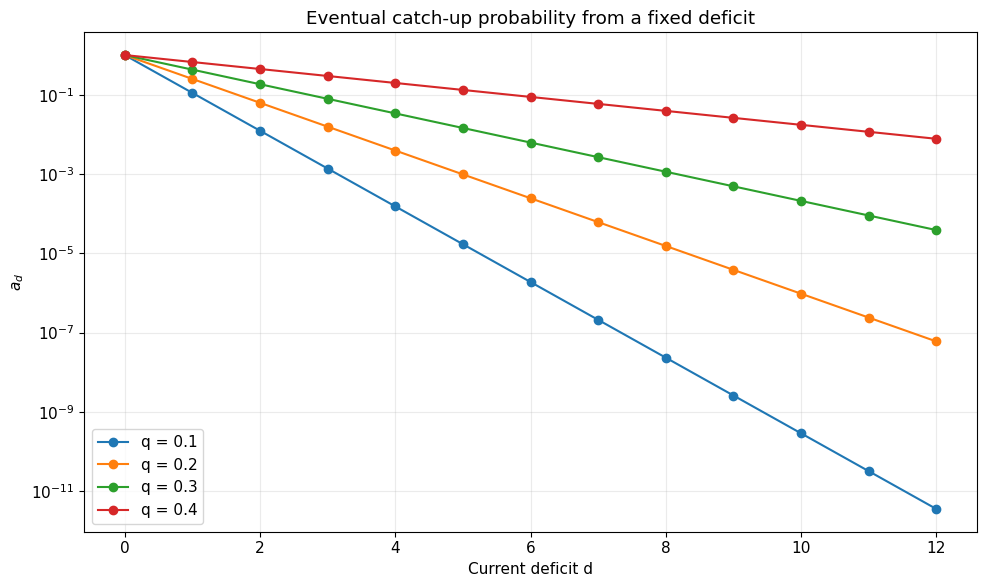

,q=0.1,q=0.2,q=0.3,q=0.4
Deficit d,,,,
0,1.000000,1.000000,1.000000,1.000000
1,0.111111,0.250000,0.428571,0.666667
2,0.012346,0.062500,0.183673,0.444444
3,0.001372,0.015625,0.078717,0.296296
4,0.000152,0.003906,0.033736,0.197531
5,0.000017,0.000977,0.014458,0.131687
6,0.000002,0.000244,0.006196,0.087791
7,0.000000,0.000061,0.002656,0.058528


In [7]:
def catch_up_probability_from_deficit(deficit, attacker_share):
    honest_share = 1.0 - attacker_share
    deficit = np.asarray(deficit, dtype=int)

    if attacker_share >= honest_share:
        return np.ones_like(deficit, dtype=float)

    ratio = attacker_share / honest_share
    return np.where(deficit <= 0, 1.0, ratio ** deficit).astype(float)


deficits = np.arange(0, 13)
attacker_shares = [0.1, 0.2, 0.3, 0.4]

catch_up_table = pd.DataFrame(
    {
        f"q={q:.1f}": catch_up_probability_from_deficit(deficits, q)
        for q in attacker_shares
    },
    index=deficits,
)
catch_up_table.index.name = "Deficit d"

fig, ax = plt.subplots()
for q in attacker_shares:
    ax.plot(deficits, catch_up_probability_from_deficit(deficits, q), marker="o", label=f"q = {q:.1f}")
ax.set_title("Eventual catch-up probability from a fixed deficit")
ax.set_xlabel("Current deficit d")
ax.set_ylabel(r"$a_d$")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
plt.show()

catch_up_table.head(8)



The log-scale plot highlights the geometric structure very clearly. For each fixed attacker share $q<0.5$, the graph becomes an approximately straight line because

$$
\log a_d = d \log\!\left(\frac{q}{p}\right).
$$

That is exactly what exponential decay looks like after applying a logarithm. The slope becomes less negative as $q$ approaches $0.5$, which means the decay becomes slower and security improves less quickly.



### 3.3 Attacker progress during the confirmation window

The fixed-deficit formula is not yet the final answer, because a merchant does not usually ask: "What if the attacker starts $d$ blocks behind right now?" Instead, the merchant waits for $z$ confirmations while the attacker is already mining a private branch.

Let $K$ be the number of attacker blocks found **before** the honest network accumulates $z$ blocks. Then the attacker is not necessarily $z$ blocks behind when the merchant accepts the payment. The actual remaining deficit is

$$
d = z - K.
$$

This random variable $K$ follows a **negative binomial distribution**:

$$
\Pr(K = k) = \binom{k+z-1}{k} p^z q^k,
\qquad k = 0,1,2,\dots
$$

Why is that the correct formula?

- We stop exactly when the $z$-th honest block appears.
- Before that final honest block, the attacker may have produced $k$ secret blocks.
- In the first $k+z-1$ block discoveries, we must see exactly $k$ attacker blocks and $z-1$ honest blocks.
- The last discovery is forced to be honest.

That is precisely the counting logic behind the negative binomial model.

Its first two moments are especially informative:

$$
\mathbb{E}[K] = \frac{zq}{p},
\qquad
\mathrm{Var}(K) = \frac{zq}{p^2}.
$$

The expectation tells us the average attacker progress during the waiting window. The variance tells us that the hidden progress can fluctuate substantially, especially when $q$ is not tiny.


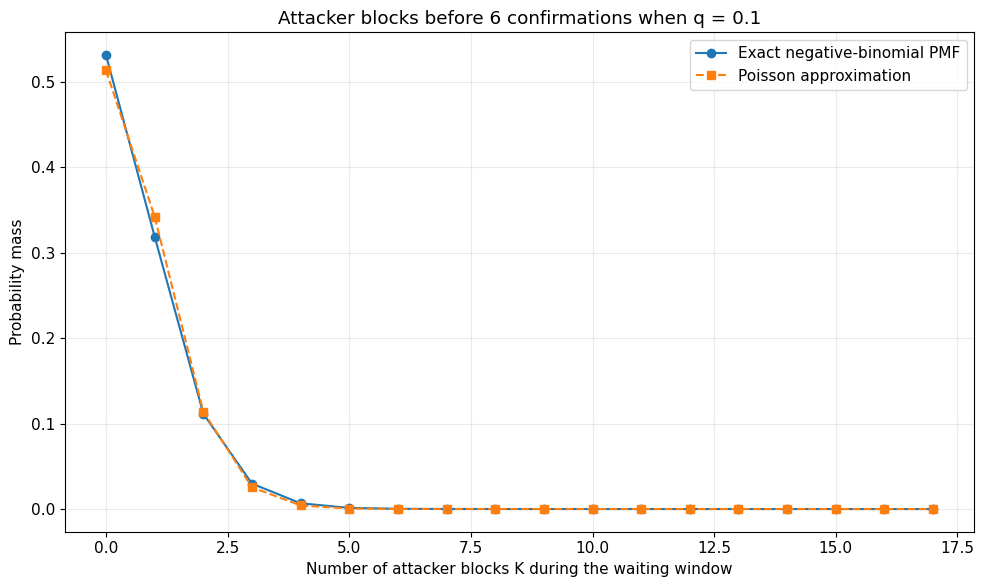

,Expected attacker blocks E[K],Variance Var(K),Standard deviation
"q = 0.1, z = 6",0.666667,0.740741,0.860663
"q = 0.3, z = 6",2.571429,3.673469,1.916630


In [14]:
def negative_binomial_attacker_pmf(k_values, confirmations, attacker_share):
    honest_share = 1.0 - attacker_share
    k_values = np.asarray(k_values, dtype=int)

    log_coeff = (
        np.vectorize(lgamma)(k_values + confirmations)
        - np.vectorize(lgamma)(k_values + 1)
        - lgamma(confirmations)
    )
    log_pmf = (
        log_coeff
        + confirmations * np.log(honest_share)
        + k_values * np.log(attacker_share)
    )
    return np.exp(log_pmf)


def poisson_attacker_pmf(k_values, confirmations, attacker_share):
    honest_share = 1.0 - attacker_share
    lam = confirmations * attacker_share / honest_share
    k_values = np.asarray(k_values, dtype=int)

    log_pmf = -lam + k_values * np.log(lam) - np.vectorize(lgamma)(k_values + 1)
    log_pmf = np.where(k_values == 0, -lam, log_pmf)
    return np.exp(log_pmf)


def expected_attacker_blocks(confirmations, attacker_share):
    honest_share = 1.0 - attacker_share
    return confirmations * attacker_share / honest_share


def variance_attacker_blocks(confirmations, attacker_share):
    honest_share = 1.0 - attacker_share
    return confirmations * attacker_share / (honest_share ** 2)


q_small = 0.1
z_wait = 6
k_values = np.arange(0, 18)

pmf_exact_small = negative_binomial_attacker_pmf(
    k_values,
    confirmations=z_wait,
    attacker_share=q_small
)
pmf_poisson_small = poisson_attacker_pmf(
    k_values,
    confirmations=z_wait,
    attacker_share=q_small
)

fig, ax = plt.subplots()
ax.plot(k_values, pmf_exact_small, marker="o", label="Exact negative-binomial PMF")
ax.plot(k_values, pmf_poisson_small, marker="s", linestyle="--", label="Poisson approximation")
ax.set_title("Attacker blocks before 6 confirmations when q = 0.1")
ax.set_xlabel("Number of attacker blocks K during the waiting window")
ax.set_ylabel("Probability mass")
ax.legend()
fig.tight_layout()
plt.show()

moment_table = pd.DataFrame(
    {
        "Expected attacker blocks E[K]": [
            expected_attacker_blocks(6, 0.1),
            expected_attacker_blocks(6, 0.3),
        ],
        "Variance Var(K)": [
            variance_attacker_blocks(6, 0.1),
            variance_attacker_blocks(6, 0.3),
        ],
        "Standard deviation": [
            np.sqrt(variance_attacker_blocks(6, 0.1)),
            np.sqrt(variance_attacker_blocks(6, 0.3)),
        ],
    },
    index=["q = 0.1, z = 6", "q = 0.3, z = 6"],
)

moment_table

For $q=0.1$ and $z=6$, the distribution is concentrated near very small attacker progress, which matches intuition: a weak attacker usually finds few blocks while the honest chain advances by six. Even in this mild case, however, the mass is not concentrated at $K=0$. The attacker often finds one or two secret blocks before the merchant accepts the payment, and those blocks matter because the fixed-deficit catch-up probability is exponentially sensitive to the remaining deficit.


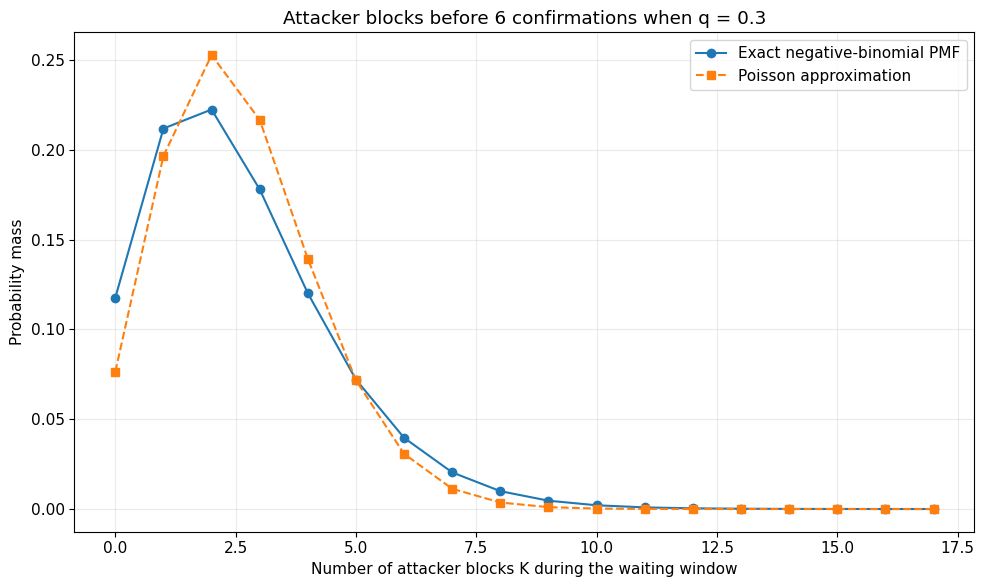

,K,Exact PMF (q = 0.3),Poisson PMF (q = 0.3),Absolute difference
0,0,0.117649,0.076426,0.041223
1,1,0.211768,0.196525,0.015243
2,2,0.222357,0.252675,0.030318
3,3,0.177885,0.216578,0.038693
4,4,0.120073,0.139229,0.019156
5,5,0.072044,0.071603,0.000440
6,6,0.039624,0.030687,0.008937
7,7,0.020378,0.011273,0.009105
8,8,0.009934,0.003623,0.006311
9,9,0.004636,0.001035,0.003601


In [15]:
q_large = 0.3
z_wait = 6
k_values = np.arange(0, 18)

pmf_exact_large = negative_binomial_attacker_pmf(
    k_values,
    confirmations=z_wait,
    attacker_share=q_large
)
pmf_poisson_large = poisson_attacker_pmf(
    k_values,
    confirmations=z_wait,
    attacker_share=q_large
)

fig, ax = plt.subplots()
ax.plot(k_values, pmf_exact_large, marker="o", label="Exact negative-binomial PMF")
ax.plot(k_values, pmf_poisson_large, marker="s", linestyle="--", label="Poisson approximation")
ax.set_title("Attacker blocks before 6 confirmations when q = 0.3")
ax.set_xlabel("Number of attacker blocks K during the waiting window")
ax.set_ylabel("Probability mass")
ax.legend()
fig.tight_layout()
plt.show()

pmf_comparison_table = pd.DataFrame(
    {
        "K": k_values,
        "Exact PMF (q = 0.3)": pmf_exact_large,
        "Poisson PMF (q = 0.3)": pmf_poisson_large,
        "Absolute difference": np.abs(pmf_exact_large - pmf_poisson_large),
    }
)

pmf_comparison_table.head(10)

When $q=0.3$, the distribution shifts visibly to the right. The attacker now accumulates meaningful hidden progress during the confirmation window, and the Poisson approximation becomes less obviously faithful to the exact negative-binomial law. This is an early hint that the final attack probabilities may also deviate.



### 3.4 Exact double-spend success probability

We now combine the two previous pieces.

Before writing the formula, here is the idea in one sentence:

> **We look at every possible amount of hidden attacker progress, compute the success chance in that case, and then average those chances using the probabilities of the cases.**

In symbols:

- the attacker mines $K$ secret blocks while the honest network reaches $z$ confirmations,
- after that point, the remaining deficit is $z-K$,
- and conditional on that deficit, the eventual catch-up probability is $a_{z-K}$.

Therefore the **exact** attack success probability is the weighted average

$$
P_{\text{exact}}(z,q)
= \sum_{k=0}^{\infty} \Pr(K=k)\,a_{z-k}.
$$

Substituting the formulas derived above gives

$$
P_{\text{exact}}(z,q)
=
\sum_{k=0}^{\infty}
\binom{k+z-1}{k} p^z q^k
\cdot
\begin{cases}
1, & k \ge z, \\
\left(\frac{q}{p}\right)^{z-k}, & k < z,
\end{cases}
\qquad p = 1-q.
$$

This formula is exact under our assumptions. It is the central object of the project.


This is a good place to slow down when reading. The formula is not conceptually difficult; it is just a careful bookkeeping rule that adds together many possible scenarios.


### 3.5 Nakamoto's Poisson approximation

In the Bitcoin whitepaper, the hidden attacker progress is approximated by a Poisson random variable with parameter

$$
\lambda = \frac{zq}{p}.
$$

Under that approximation,

$$
K \approx \mathrm{Poisson}(\lambda),
\qquad
\Pr(K=k) \approx e^{-\lambda}\frac{\lambda^k}{k!}.
$$

That yields the approximate success probability

$$
P_{\text{Poisson}}(z,q)
=
\sum_{k=0}^{\infty}
e^{-\lambda}\frac{\lambda^k}{k!}
\cdot
\begin{cases}
1, & k \ge z, \\
\left(\frac{q}{p}\right)^{z-k}, & k < z.
\end{cases}
$$

The Poisson model is elegant and historically important, but it is still an approximation. One of the main goals of the notebook is to measure how far it deviates from the exact negative-binomial calculation.
